In [1]:
""" Rank the variables according to the carbon fluxes in Paul's observations """
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *

date = '20240101'
prefix = f'UQ_{date}_OAT'
N = 1850
BLOCK = 50
n_samples = 50 # number of samples generated per variable
VAR_LIST = ['AGBiomass_Spruce', 'AGBiomass_Tamarack', 'AGBiomass_Shrub',
            'AGNPPtoBiomass_Spruce', 'AGNPPtoBiomass_Tamarack', 'AGNPPtoBiomass_Shrub',
            'AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
            'BGNPP_TreeShrub', 'BGtoAG_TreeShrub', 'NPP', 'HR', 'NEE'] # , 'TOTSOMC']
VAR_SUBSET = ['AGNPP_Spruce', 'AGNPP_Tamarack', 'AGNPP_Shrub', 'NPP_moss',
              'BGNPP_TreeShrub', 'HR']
varid_subset = np.array([i for i in range(len(VAR_LIST)) if VAR_LIST[i] in VAR_SUBSET])

# The dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
collect = np.empty([N, len(VAR_LIST), 2, 4], float)
for b in range(0, N // BLOCK):
    collect[(b*BLOCK):((b + 1)*BLOCK), :, :, :] = np.load(os.path.join(path_out, "extract", prefix, f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)[:, 1:, :, :] # TEMPORARY
# convert Inf's to NaN
collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
# revert the signs of NEE & HR to be compatible with Paul's data
# collect[:, -3:-1, :, :] = - collect[:, -3:-1, :, :]
# TEMPORARY
collect[:, -2:, :, :] = - collect[:, -2:, :, :]

In [2]:
# Get the sample values
samples = np.loadtxt(os.path.join('calibration_files', f'mcsamples_{date}_OAT.txt'))
names = pd.read_csv(os.path.join('calibration_files', f'parm_file_{date}_OAT'), sep = ' ', 
                    header=None, index_col = [0,1])

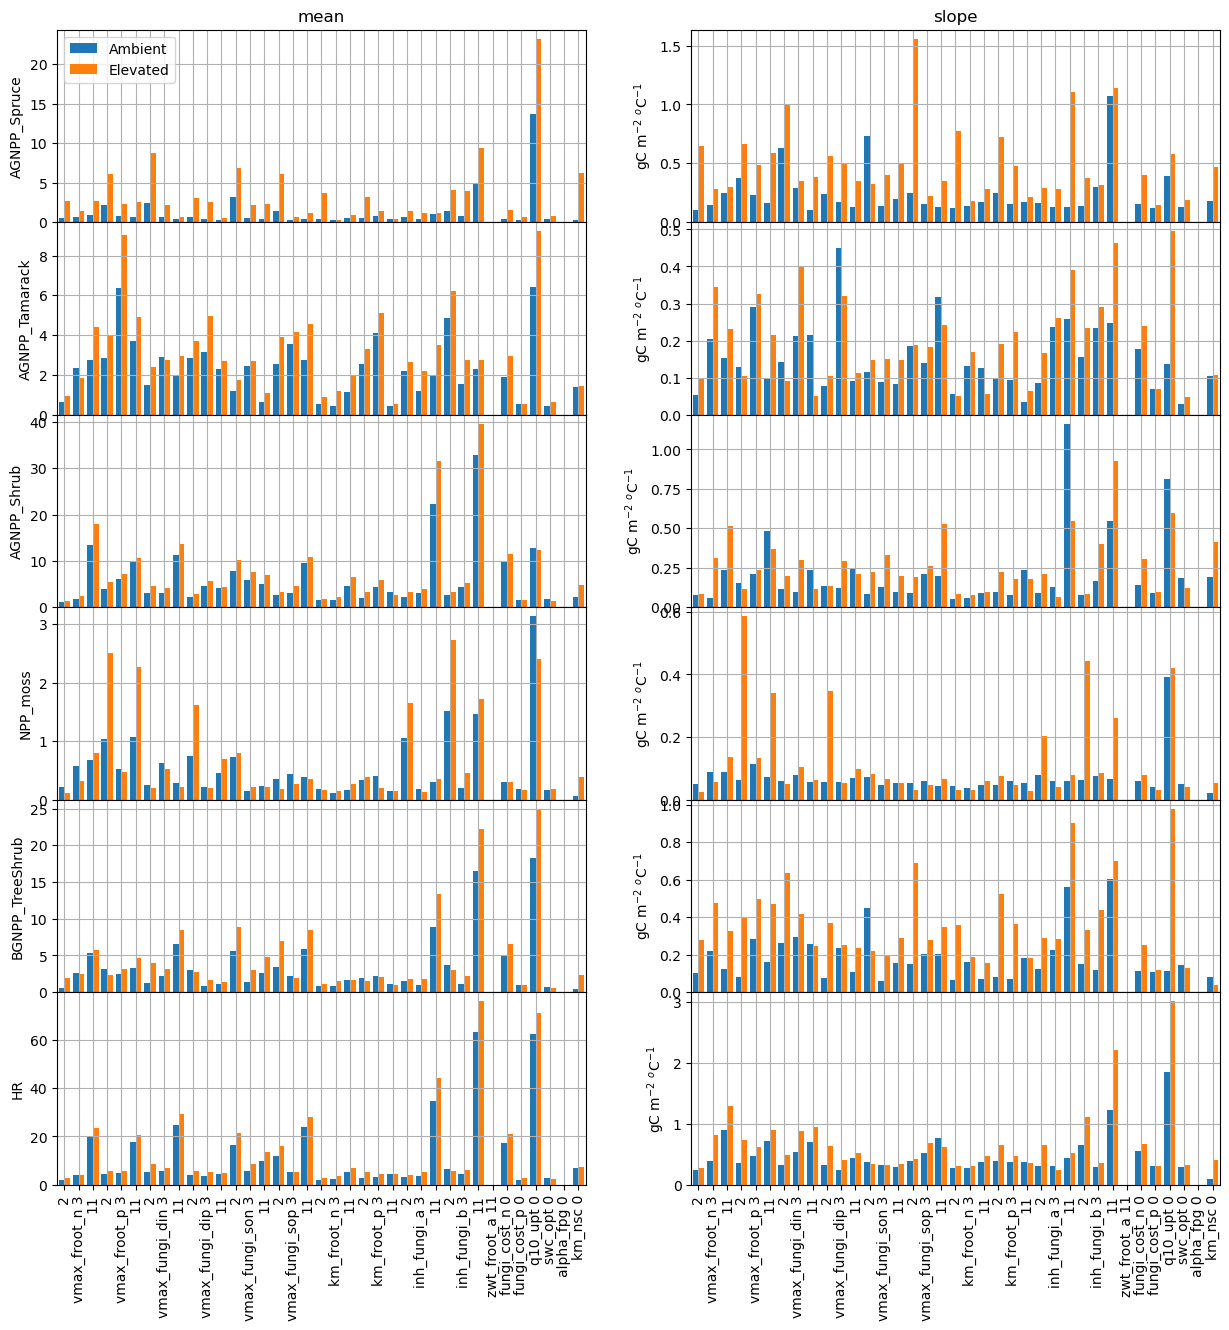

In [3]:
######################################################
# Plot the sensitivity of the different parameters
######################################################

# create xtick labels - when multiple PFTs, put pft label in only one
parlist_labels = []
for i, (parname, pft) in enumerate(names.index):
    if (i < 30) and (pft != 3):
        parlist_labels.append(pft)
    else:
        parlist_labels.append(f'{parname} {pft}')

#
fig, axes = plt.subplots(len(varid_subset), 2, figsize = (15, 15), sharey = False, sharex = True)
fig.subplots_adjust(hspace = 0)
for v, varid in enumerate(varid_subset):

    result_mean_std = np.full([names.shape[0], 2], np.nan)
    result_slope_std = np.full([names.shape[0], 2], np.nan)

    for i, (parname, pft) in enumerate(names.index):
        # mean - 0, slope - 2
        result_mean = collect[(i*n_samples):((i+1)*n_samples),varid,:,0]
        result_slope = collect[(i*n_samples):((i+1)*n_samples),varid,:,2]
        # calculate the CV (%) resulting from parameter variation
        result_mean_std[i, :] = np.std(result_mean, axis = 0) #/ \
            #np.mean(np.abs(result_mean), axis = 0) * 100
        result_slope_std[i, :] = np.std(result_slope, axis = 0) #/ \
            #np.mean(np.abs(result_slope), axis = 0) * 100

    ax = axes[v, 0]
    for c, co2 in enumerate(['amb', 'elev']):
        ax.bar(height = result_mean_std[:, c], 
               x = np.arange(1, names.shape[0]+1) + 0.4 * c - 0.2, 
               width = 0.4)
    ax.set_xticks(np.arange(1, names.shape[0]+1))
    ax.set_xticklabels(parlist_labels, rotation = 90)
    #ax.set_ylim([0, 25])
    ax.set_xlim([0.5, names.shape[0] + 0.5])
    ax.grid(True)
    #ax.set_ylabel('CV (%)') 
    ax.set_ylabel('gC m$^{-2}$')
    if v == 0:
        ax.set_title('mean')
        ax.legend(['Ambient','Elevated'])
    ax.set_ylabel(VAR_LIST[varid])

    ax = axes[v, 1]
    for c, co2 in enumerate(['amb', 'elev']):
        ax.bar(height = result_slope_std[:, c], 
               x = np.arange(1, names.shape[0]+1) + 0.4 * c - 0.2, 
               width = 0.4)
    ax.set_xticks(np.arange(1, names.shape[0]+1))
    ax.set_xticklabels(parlist_labels, rotation = 90)
    #ax.set_ylim([0, 125])
    ax.set_xlim([0.5, names.shape[0] + 0.5])
    ax.grid(True)
    #ax.set_ylabel('CV (%)')
    ax.set_ylabel('gC m$^{-2}$ $^o$C$^{-1}$')
    if v == 0:
        ax.set_title('slope')

Text(0, 0.5, 'Rank of sensitivity')

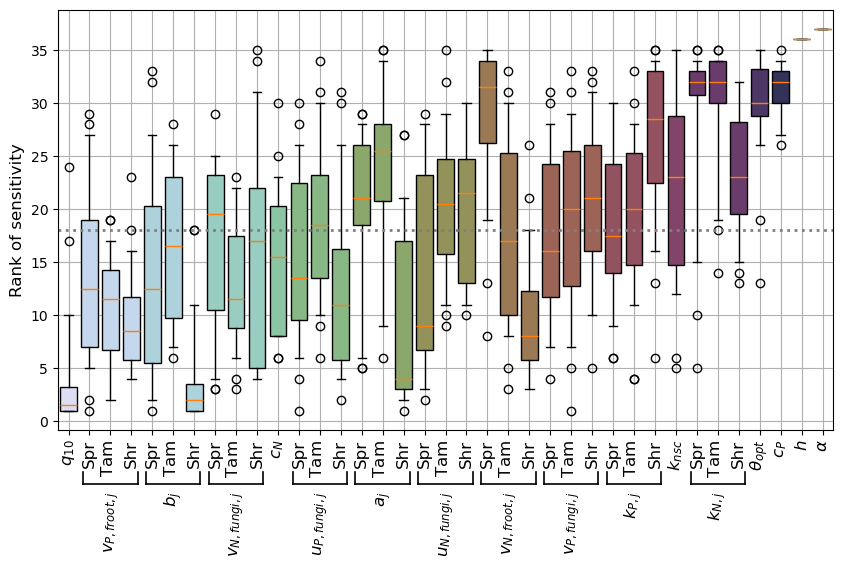

In [4]:
######################################################
# Plot the ranks of the sensitivity of the parameters
# (use errorbars to indicate across different variables)
######################################################

# Obtain the ranks of each parameter: smaller rank = greater sensitivity
# dimensions: parameter, variable, [mean, slope], [aco2, eco2]
collect_rank = np.empty([names.shape[0], len(varid_subset), 2, 2], dtype = int)
for v, varid in enumerate(varid_subset):

    result_mean_std = np.full([names.shape[0], 2], np.nan)
    result_slope_std = np.full([names.shape[0], 2], np.nan)
    for i, (parname, pft) in enumerate(names.index):
        # mean - 0, slope - 2
        result_mean = collect[(i*n_samples):((i+1)*n_samples),varid,:,0]
        result_slope = collect[(i*n_samples):((i+1)*n_samples),varid,:,2]
        # calculate the CV (%) resulting from parameter variation
        result_mean_std[i, :] = np.std(result_mean, axis = 0) #/ \
            #np.mean(np.abs(result_mean), axis = 0) * 100
        result_slope_std[i, :] = np.std(result_slope, axis = 0) #/ \
            #np.mean(np.abs(result_slope), axis = 0) * 100

    for j in range(2):
        collect_rank[:, v, 0, j] = np.argsort(-result_mean_std[:,j]).argsort() + 1
        collect_rank[:, v, 1, j] = np.argsort(-result_slope_std[:,j]).argsort() + 1

# Sort the ranks and the xticklabels
collect_rank_sorted = {parname: [] for parname in names.index.levels[0]}
collect_rank_sorted_mean = {}
collect_rank_sorted_pft = {}
for i, (parname, pft) in enumerate(names.index):
    collect_rank_sorted[parname].append(collect_rank[i,:,:,:].reshape(-1))
    collect_rank_sorted_mean[parname] = np.mean(collect_rank_sorted[parname])
    collect_rank_sorted_pft[(parname, pft)] = np.median(collect_rank_sorted[parname])
collect_rank_sorted_mean = pd.Series(collect_rank_sorted_mean).sort_values()
collect_rank_sorted_pft = pd.Series(collect_rank_sorted_pft).sort_values()

# parname => parameter name in the paper
papernames = {'vmax_froot_n': '$v_{N,froot,j}$', 'vmax_froot_p': '$v_{P,froot,j}$', 
              'vmax_fungi_din': '$v_{N,fungi,j}$', 'vmax_fungi_dip': '$v_{P,fungi,j}$', 
              'vmax_fungi_son': '$u_{N,fungi,j}$', 'vmax_fungi_sop': '$u_{P,fungi,j}$',
              'km_froot_n': '$k_{N,j}$', 'km_froot_p': '$k_{P,j}$', 
              'inh_fungi_a': '$a_j$', 'inh_fungi_b': '$b_j$', 
              'zwt_froot_a': '$h$', 'fungi_cost_n': '$c_N$', 'fungi_cost_p': '$c_P$', 
              'q10_upt': '$q_{10}$', 'swc_opt': r'${\theta}_{opt}$', 
              'alpha_fpg': r'${\alpha}$', 'km_nsc': '$k_{nsc}$'}

# Plot the ranks
cmap = sns.cubehelix_palette(n_colors = 256, start=2, rot=1.5, dark=0.1, light=0.9, as_cmap=True)
clist = [cmap((i+0.5)/len(collect_rank_sorted_mean)) for i in range(len(collect_rank_sorted_mean))]
collect_rank_stacked = collect_rank.reshape([names.shape[0], -1])
fig, ax = plt.subplots(figsize = (10, 7))

# Make a bit more room under the axis for the bracket
plt.subplots_adjust(bottom=0.28)

count = 1
parlist_labels = []

# Track positions for Spr/Tam/Shr per parameter
from collections import defaultdict
param_pft_pos = defaultdict(dict)   # {parname: { 'Spr': xpos, 'Tam': xpos, 'Shr': xpos }}

for p, parname in enumerate(collect_rank_sorted_mean.index):
    for pft, pft_name in zip([0, 2, 3, 11], ['', 'Spr', 'Tam', 'Shr']):
        i = np.where((names.index.get_level_values(0) == parname) &
                     (names.index.get_level_values(1) == pft))[0]
        if len(i) > 0:
            i = i[0]
            bbox = ax.boxplot(collect_rank_stacked[i], positions = [count], whis = [5, 95],
                              patch_artist = True, widths = 0.8)
            for box_elem in bbox['boxes']:
                box_elem.set_facecolor(clist[p])

            # record x-position for Spr/Tam/Shr
            if pft_name in ('Spr', 'Tam', 'Shr'):
                param_pft_pos[parname][pft_name] = count

            if (i < 30) and (pft != 3):
                parlist_labels.append(pft_name)
            else:
                if parname == 'zwt_froot_a'  or pft_name == '':
                    parlist_labels.append(papernames[parname])
                else:
                    parlist_labels.append(f'{papernames[parname]}   {pft_name}')
            count += 1

# --- Draw bottom black brackets spanning Spr..Shr for each parameter that has all three ---
# Use x-axis transform so y is in axes-fraction (fixed under ticks), x is in data coords.
xaxis_transform = ax.get_xaxis_transform()
def draw_bottom_bracket(ax, x0, x1, y_ax=-0.095, cap_h_ax=0.03):
    # Horizontal line
    ax.plot([x0-0.3, x1+0.3], [y_ax, y_ax], transform=xaxis_transform,
            color='black', linewidth=1.2, clip_on=False, zorder=5)
    # End caps
    ax.plot([x0-0.3, x0-0.3], [y_ax, y_ax + cap_h_ax], transform=xaxis_transform,
            color='black', linewidth=1.2, clip_on=False, zorder=5)
    ax.plot([x1+0.3, x1+0.3], [y_ax, y_ax + cap_h_ax], transform=xaxis_transform,
            color='black', linewidth=1.2, clip_on=False, zorder=5)

for parname, triples in param_pft_pos.items():
    if all(k in triples for k in ('Spr', 'Tam', 'Shr')):
        xs = [triples[k] for k in ('Spr', 'Tam', 'Shr')]
        x0, x1 = min(xs), max(xs)
        # Draw the bracket under the ticks (tweak y_ax/cap_h_ax if your labels are larger/smaller)
        draw_bottom_bracket(ax, x0, x1, y_ax=-0.13, cap_h_ax=0.03)

ax.axhline(y = 18, color = 'grey', linestyle = ':', linewidth = 2)

ax.set_xticks(np.arange(1, names.shape[0]+1))
ax.set_xticklabels(parlist_labels, rotation=90, fontsize=12)
ax.set_xlim([0.5, names.shape[0] + 0.5])
ax.grid(True)
ax.set_ylabel('Rank of sensitivity', fontsize=12)

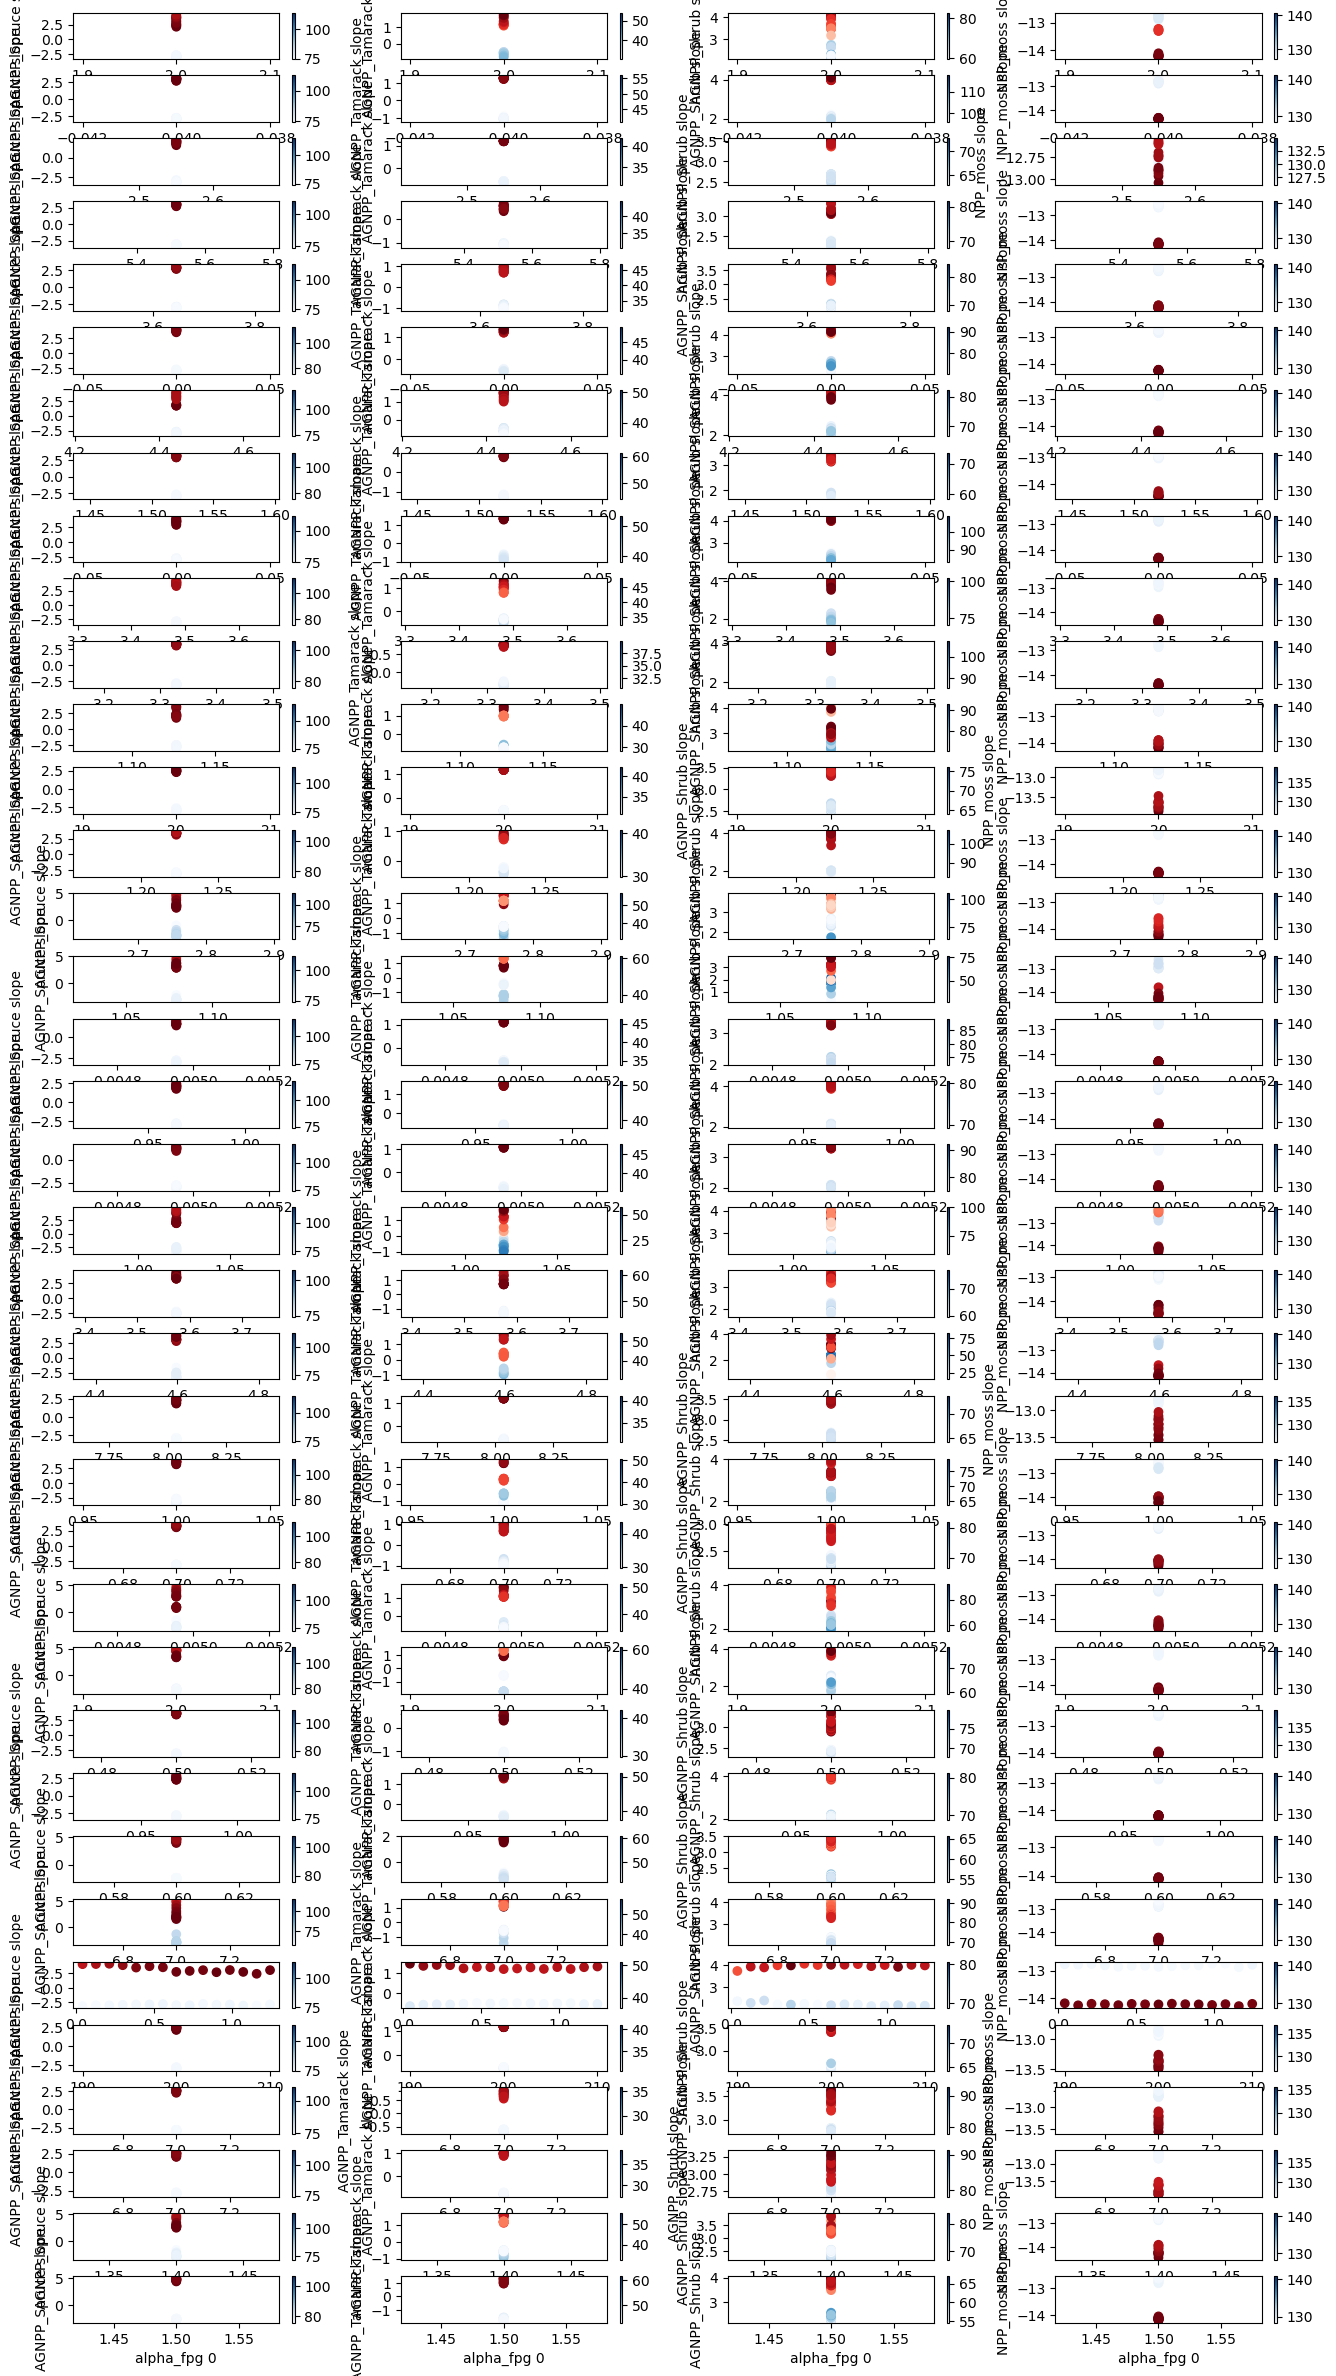

In [5]:
######################################################
# Plot the partial dependence plot for the most 
# sensitive parameters
######################################################
params = list(collect_rank_sorted_pft.index)
fig, axes = plt.subplots(len(params), 4, figsize = (16, 30), sharey = False, sharex = False)
fig.subplots_adjust(hspace = 0.35, wspace = 0.27)
for v in range(4):
    varid = varid_subset[v]

    for p, (parname0, pft0) in enumerate(params):
        for i, (parname, pft) in enumerate(names.index):
            parfiles = samples[(i*15):(i*15+15), i]
            if (parname == parname0) & (pft == pft0):
                # mean - 0, slope - 2
                result_mean = collect[(i*15):(i*15+15),varid,:,0]
                result_slope = collect[(i*15):(i*15+15),varid,:,2]

                ax = axes[p, v]
                cf1 = ax.scatter(parfiles, result_slope[:, 0], c = result_mean[:, 0], 
                                 cmap = 'Blues', label = 'amb', vmin = result_mean.min(), 
                                 vmax = result_mean.max())
                cf2 = ax.scatter(parfiles, result_slope[:, 1], c = result_mean[:, 1], 
                                 cmap = 'Reds', label = 'elev', vmin = result_mean.min(), 
                                 vmax = result_mean.max())

                ax.set_xlabel(f'{parname} {pft}')
                #ax.set_xlabel(f'{VAR_LIST[varid]} mean')
                ax.set_ylabel(f'{VAR_LIST[varid]} slope')

                plt.colorbar(cf1, ax = ax)
                #plt.colorbar(cf2, ax = ax)